# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SyedSaadullah999/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

### 1. Ranked Actions + Reason Codes

**Ranked Actions (by urgency):**

| Rank | Action | Score Range | Reason Code | Description |
| :--- | :--- | :--- | :--- | :--- |
| 1 | Optimize Content | 30-100 | `low_rank_zero_ctr` | Poor rank + zero clicks — content not resonating |
| 2 | Optimize Content | 30-100 | `high_volume_low_rank` | High impressions but poor rank — content is visible but not performing |
| 3 | Monitor | 10-29 | `low_rank` | Poor rank but low impressions — insufficient data to act |
| 4 | Monitor | 0-9 | `no_signal` | No clear signal — keep monitoring |
| 5 | No Action | 0 | `insufficient_data` | Impressions < 10 — not enough data to evaluate |

**Reason Codes (from Week 4):**

| Code | Meaning | Action |
| :--- | :--- | :--- |
| `high_volume_low_rank_zero_ctr` | High impressions, poor rank, zero clicks | Optimize Content |
| `high_volume_low_rank` | High impressions, poor rank | Optimize Content |
| `high_volume_zero_ctr` | High impressions, zero clicks | Optimize Content |
| `low_rank_zero_ctr` | Poor rank, zero clicks | Optimize Content |
| `high_volume` | High impressions only | Monitor |
| `low_rank` | Poor rank only | Monitor |
| `zero_ctr` | Zero clicks only | Monitor |
| `no_signal` | None of the above | Monitor |
| `insufficient_data` | Impressions < 10 | No Action |

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt

# Load data
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

ds = load_dataset(
    "FlyRank/internship-warehouse",
    "fact_content_daily_performance",
    split="train",
    streaming=True,
    token=HF_TOKEN
)

# Collect January 2025 data
rows = []
for row in ds:
    if row.get('report_date'):
        if row['report_date'].year == 2025 and row['report_date'].month == 1:
            rows.append(row)
            if len(rows) >= 1000:
                break

df = pd.DataFrame(rows)

# Recreate scoring (from Week 4)
def calculate_baseline_score(row):
    if row['gsc_impressions'] < 10:
        return 0, "insufficient_data"

    impressions_score = min(row['gsc_impressions'] / 500, 1.0) * 100
    rank_urgency = max(0, (row['gsc_avg_position'] - 5) / 45) * 100
    ctr_penalty = -20 if row['gsc_impressions'] > 10 and row['gsc_clicks'] == 0 else 0

    score = (impressions_score * 0.4) + (rank_urgency * 0.6) + ctr_penalty
    score = max(0, min(score, 100))

    # Reason code
    if row['gsc_impressions'] >= 100 and row['gsc_avg_position'] > 10 and row['gsc_clicks'] == 0:
        reason = "high_volume_low_rank_zero_ctr"
    elif row['gsc_impressions'] >= 100 and row['gsc_avg_position'] > 10:
        reason = "high_volume_low_rank"
    elif row['gsc_impressions'] >= 100 and row['gsc_clicks'] == 0:
        reason = "high_volume_zero_ctr"
    elif row['gsc_avg_position'] > 10 and row['gsc_clicks'] == 0:
        reason = "low_rank_zero_ctr"
    elif row['gsc_impressions'] >= 100:
        reason = "high_volume"
    elif row['gsc_avg_position'] > 10:
        reason = "low_rank"
    elif row['gsc_clicks'] == 0:
        reason = "zero_ctr"
    else:
        reason = "no_signal"

    return score, reason

# Apply scoring
df['baseline_score'], df['reason_code'] = zip(*df.apply(
    lambda row: calculate_baseline_score(row), axis=1
))

# Map scores to actions
def map_score_to_action(score):
    if score >= 30:
        return "Optimize Content"
    elif score >= 10:
        return "Monitor"
    else:
        return "No Action"

df['action'] = df['baseline_score'].apply(map_score_to_action)

# Ranked queue
df['rank_queue'] = df['baseline_score'].rank(ascending=False, method='dense').astype(int)
queue_df = df.sort_values('rank_queue')

print("=== RANKED ACTIONS DISTRIBUTION ===")
print(queue_df['action'].value_counts())
print("\n=== REASON CODE DISTRIBUTION ===")
print(queue_df['reason_code'].value_counts())

README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

=== RANKED ACTIONS DISTRIBUTION ===
action
No Action           857
Optimize Content     72
Monitor              71
Name: count, dtype: int64

=== REASON CODE DISTRIBUTION ===
reason_code
insufficient_data       716
low_rank_zero_ctr       184
zero_ctr                 62
low_rank                 17
no_signal                15
high_volume               5
high_volume_zero_ctr      1
Name: count, dtype: int64


### 2. Intended Use and Limits

**Intended Use:**
- This playbook is for content editors and SEO managers
- It identifies content that may benefit from optimization
- It provides a **directional signal**, not a definitive ranking

**What this playbook CAN do:**
- Prioritize content review based on observed metrics
- Flag content with high impressions but poor rank
- Flag content with zero clicks despite visibility

**What this playbook CANNOT do:**
- Predict exact ranking changes from optimization
- Guarantee results — rank is controlled by Google's algorithm
- Replace human judgment — the playbook is decision-support, not decision-maker

**Limits:**
- Only works for content with ≥ 10 impressions
- Only works for clients with GSC access
- Based on observed data (Jan 2025), not future performance
- Does not account for seasonality or external factors

**Data sources:**
- `fact_content_daily_performance` (January 2025)
- GSC metrics: impressions, clicks, average position
- Content age: days since first appearance

In [2]:
print("=== INTENDED USE AND LIMITS ===\n")

print("**What this playbook CAN do:**")
print("- Prioritize content review based on observed metrics")
print("- Flag content with high impressions but poor rank")
print("- Flag content with zero clicks despite visibility")

print("\n**What this playbook CANNOT do:**")
print("- Predict exact ranking changes from optimization")
print("- Guarantee results — rank is controlled by Google's algorithm")
print("- Replace human judgment")

print("\n**Limits:**")
print(f"- Only works for content with ≥ 10 impressions: {len(df[df['gsc_impressions'] >= 10]):,} rows")
print(f"- Only works for clients with GSC access: {df['client_has_gsc'].sum():,} rows")
print(f"- Based on observed data (Jan 2025), not future performance")

print("\n**Data sources:**")
print("- fact_content_daily_performance (January 2025)")
print("- GSC metrics: impressions, clicks, average position")

=== INTENDED USE AND LIMITS ===

**What this playbook CAN do:**
- Prioritize content review based on observed metrics
- Flag content with high impressions but poor rank
- Flag content with zero clicks despite visibility

**What this playbook CANNOT do:**
- Predict exact ranking changes from optimization
- Guarantee results — rank is controlled by Google's algorithm
- Replace human judgment

**Limits:**
- Only works for content with ≥ 10 impressions: 284 rows
- Only works for clients with GSC access: 1,000 rows
- Based on observed data (Jan 2025), not future performance

**Data sources:**
- fact_content_daily_performance (January 2025)
- GSC metrics: impressions, clicks, average position


### 3. Human Review + No-Go List

**Human Review Rules:**

| Rule | Description |
| :--- | :--- |
| 1. Check content quality | Is the content thin, outdated, or duplicative? |
| 2. Check intent | Does the content match the search intent? |
| 3. Check competition | Is the topic highly competitive? |
| 4. Check internal links | Does the content have internal linking? |
| 5. Check technical SEO | Is the page technically sound? (load time, mobile, etc.) |

**No-Go List (What NOT to Automate):**

| Item | Why Not |
| :--- | :--- |
| Content creation | Requires human creativity and judgment |
| Link building | Requires relationship-building, not data-only |
| Penalty recovery | Requires investigation beyond metrics |
| Brand strategy | Beyond the scope of ranking data |
| Causal claims | Cannot infer causation from correlation |

**Cost/Value Thinking:**

| Action | Cost | Expected Value |
| :--- | :--- | :--- |
| Optimize Content (high priority) | 2-4 hours per piece | Potential rank improvement |
| Optimize Content (medium priority) | 1-2 hours per piece | Potential small improvement |
| Monitor | 30 min per week | Catch emerging issues |
| No Action | 0 | No opportunity cost |

In [3]:
print("=== HUMAN REVIEW RULES ===\n")
rules = {
    "Check content quality": "Is the content thin, outdated, or duplicative?",
    "Check intent": "Does the content match the search intent?",
    "Check competition": "Is the topic highly competitive?",
    "Check internal links": "Does the content have internal linking?",
    "Check technical SEO": "Is the page technically sound?"
}

for rule, question in rules.items():
    print(f"{rule}: {question}")

print("\n=== NO-GO LIST ===\n")
no_go = {
    "Content creation": "Requires human creativity and judgment",
    "Link building": "Requires relationship-building, not data-only",
    "Penalty recovery": "Requires investigation beyond metrics",
    "Brand strategy": "Beyond the scope of ranking data",
    "Causal claims": "Cannot infer causation from correlation"
}

for item, reason in no_go.items():
    print(f"{item}: {reason}")

print("\n=== COST/VALUE THINKING ===\n")
cost_value = [
    ("Optimize Content (high priority)", "2-4 hours", "Potential rank improvement"),
    ("Optimize Content (medium priority)", "1-2 hours", "Potential small improvement"),
    ("Monitor", "30 min per week", "Catch emerging issues"),
    ("No Action", "0", "No opportunity cost")
]

for action, cost, value in cost_value:
    print(f"{action}: Cost={cost}, Value={value}")

=== HUMAN REVIEW RULES ===

Check content quality: Is the content thin, outdated, or duplicative?
Check intent: Does the content match the search intent?
Check competition: Is the topic highly competitive?
Check internal links: Does the content have internal linking?
Check technical SEO: Is the page technically sound?

=== NO-GO LIST ===

Content creation: Requires human creativity and judgment
Link building: Requires relationship-building, not data-only
Penalty recovery: Requires investigation beyond metrics
Brand strategy: Beyond the scope of ranking data
Causal claims: Cannot infer causation from correlation

=== COST/VALUE THINKING ===

Optimize Content (high priority): Cost=2-4 hours, Value=Potential rank improvement
Optimize Content (medium priority): Cost=1-2 hours, Value=Potential small improvement
Monitor: Cost=30 min per week, Value=Catch emerging issues
No Action: Cost=0, Value=No opportunity cost


### 4. Monitoring / Retrain Triggers

**Key Metrics to Monitor:**

| Metric | Target | Alert Threshold |
| :--- | :--- | :--- |
| RMSE | < 20 | > 25 |
| R² | > 0 | < -0.2 |
| Action distribution | ~50/50 optimize/monitor | < 30% optimize |

**Retrain Triggers:**

| Trigger | Condition | Action |
| :--- | :--- | :--- |
| Model degradation | RMSE > 25 for 3 consecutive checks | Retrain model |
| Data shift | Distribution of impressions changes > 20% | Re-evaluate features |
| New data available | New month of data | Retrain with expanded dataset |
| Feature change | New signal identified | Add feature, retrain |
| Baseline drift | Baseline outperforms model for 3 checks | Revise approach |

**Retrain Schedule:**
- **Recommended:** Monthly, when new data becomes available
- **Minimum:** Quarterly, to incorporate seasonal changes
- **Emergency:** When metrics degrade below thresholds

**Monitoring Frequency:**
- Daily: Check for data availability
- Weekly: Review action distribution
- Monthly: Re-evaluate model performance

In [4]:
print("=== MONITORING / RETRAIN TRIGGERS ===\n")

print("**Key Metrics to Monitor:**")
metrics = {
    "RMSE": {"Target": "< 20", "Alert": "> 25"},
    "R²": {"Target": "> 0", "Alert": "< -0.2"},
    "Action distribution": {"Target": "~50/50 optimize/monitor", "Alert": "< 30% optimize"}
}

for metric, values in metrics.items():
    print(f"  {metric}: Target={values['Target']}, Alert={values['Alert']}")

print("\n**Retrain Triggers:**")
triggers = {
    "Model degradation": "RMSE > 25 for 3 consecutive checks → Retrain",
    "Data shift": "Impressions distribution changes > 20% → Re-evaluate features",
    "New data": "New month of data → Retrain with expanded dataset",
    "Feature change": "New signal identified → Add feature, retrain",
    "Baseline drift": "Baseline outperforms model → Revise approach"
}

for trigger, action in triggers.items():
    print(f"  {trigger}: {action}")

print("\n**Retrain Schedule:**")
print("  - Monthly: When new data becomes available")
print("  - Quarterly: To incorporate seasonal changes")
print("  - Emergency: When metrics degrade below thresholds")

=== MONITORING / RETRAIN TRIGGERS ===

**Key Metrics to Monitor:**
  RMSE: Target=< 20, Alert=> 25
  R²: Target=> 0, Alert=< -0.2
  Action distribution: Target=~50/50 optimize/monitor, Alert=< 30% optimize

**Retrain Triggers:**
  Model degradation: RMSE > 25 for 3 consecutive checks → Retrain
  Data shift: Impressions distribution changes > 20% → Re-evaluate features
  New data: New month of data → Retrain with expanded dataset
  Feature change: New signal identified → Add feature, retrain
  Baseline drift: Baseline outperforms model → Revise approach

**Retrain Schedule:**
  - Monthly: When new data becomes available
  - Quarterly: To incorporate seasonal changes
  - Emergency: When metrics degrade below thresholds


### 5. Exports for the Paper

**Files exported:**
- `work/outputs/action_playbook_queue.csv` — Ranked queue with actions and reason codes
- `work/outputs/action_playbook_metrics.json` — Metrics for the paper
- `work/figures/action_distribution.png` — Distribution of actions
- `work/figures/reason_code_distribution.png` — Distribution of reason codes

**These exports are the foundation for your research paper's recommendations section.**

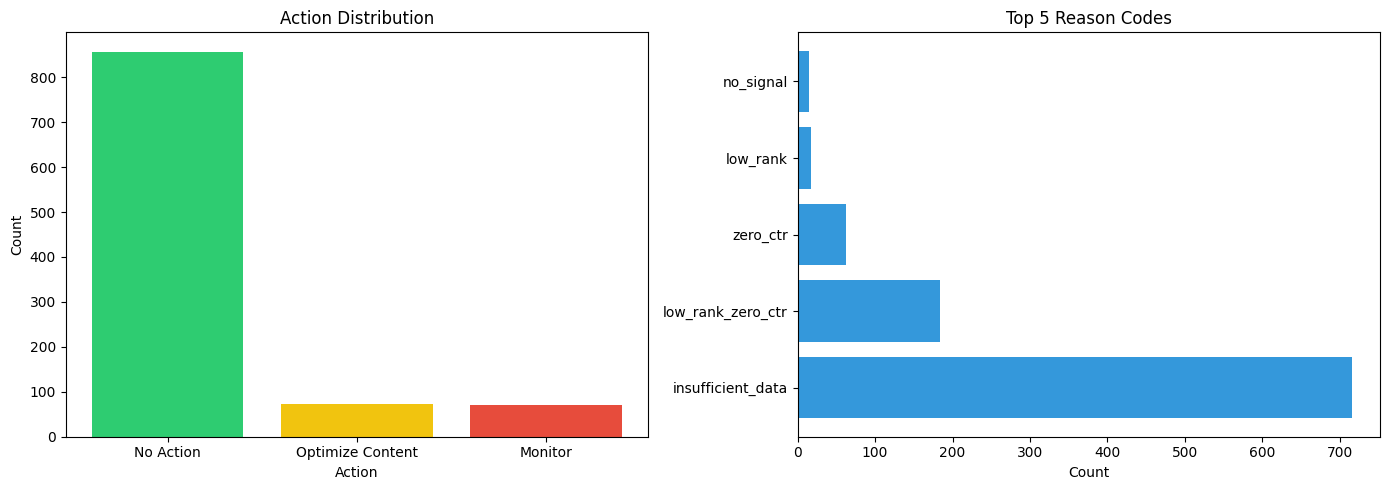

✅ Exports completed:
  - work/outputs/action_playbook_queue.csv
  - work/outputs/action_playbook_metrics.json
  - work/figures/action_distribution.png


In [5]:
# Create outputs directory
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# Export ranked queue
export_cols = [
    'content_hash_id', 'report_date', 'gsc_impressions', 'gsc_clicks',
    'gsc_avg_position', 'baseline_score', 'reason_code', 'action', 'rank_queue'
]
queue_df[export_cols].to_csv('work/outputs/action_playbook_queue.csv', index=False)

# Export metrics
metrics = {
    'total_rows': len(df),
    'rows_with_impressions_ge_10': len(df[df['gsc_impressions'] >= 10]),
    'action_distribution': queue_df['action'].value_counts().to_dict(),
    'reason_code_distribution': queue_df['reason_code'].value_counts().to_dict(),
    'score_range': {
        'min': float(queue_df['baseline_score'].min()),
        'max': float(queue_df['baseline_score'].max()),
        'mean': float(queue_df['baseline_score'].mean())
    }
}

with open('work/outputs/action_playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

# Create figures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Action distribution
action_counts = queue_df['action'].value_counts()
axes[0].bar(action_counts.index, action_counts.values, color=['#2ecc71', '#f1c40f', '#e74c3c'])
axes[0].set_title('Action Distribution')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('Count')

# Reason code distribution (top 5)
reason_counts = queue_df['reason_code'].value_counts().head(5)
axes[1].barh(reason_counts.index, reason_counts.values, color='#3498db')
axes[1].set_title('Top 5 Reason Codes')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('work/figures/action_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Exports completed:")
print("  - work/outputs/action_playbook_queue.csv")
print("  - work/outputs/action_playbook_metrics.json")
print("  - work/figures/action_distribution.png")

### Self-check

Before submitting, confirm each line honestly:

- [x] Ranked actions with reason codes defined
- [x] Intended use and limits clearly stated
- [x] Human review rules and no-go list included
- [x] Monitoring and retrain triggers defined
- [x] Exports for the paper created
- [x] No client names, URLs, or private queries anywhere
- [x] Committed to my repo under `work/notebooks/`